### LLM 답변 캐싱하기

In [ ]:
#!pip --version

pip 25.0.1 from C:\pkh20260902\ex0917\.venv\Lib\site-packages\pip (python 3.12)



In [ ]:
# !pip install dotenv

In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
#!pip install -U langchain langchain_openai

In [5]:
from dotenv import load_dotenv
import os

load_dotenv()

print("OpenAI 키:", os.getenv("OPENAI_API_KEY")[:8] + "...")
print("LANGSMITH 키:", os.getenv("LANGSMITH_API_KEY")[:8] + "...")
print("LangSmith 프로젝트:", os.getenv("LANGSMITH_PROJECT"))

OpenAI 키: sk-proj-...
LANGSMITH 키: lsv2_pt_...
LangSmith 프로젝트: test0914


In [ ]:
# !pip install langchain_teddynote

In [8]:
from dotenv import load_dotenv
from langchain_teddynote import logging

load_dotenv()
logging.langsmith("test0914")

LangSmith 추적을 시작합니다.
[프로젝트명]
test0914


In [1]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate

llm = ChatOpenAI(model="gpt-3.5-turbo")

prompt = PromptTemplate.from_template("{fruit}에 대해서 200자 내외로 요약해줘")

chain = prompt | llm

In [2]:
%%time
response = chain.invoke({"fruit": "바나나"})
print(response.content)

바나나는 탄수화물과 비타민, 미네랄이 풍부한 과일로 유명하다. 당도가 높고 부드러운 식감으로 많은 사람들이 좋아하는 과일 중 하나이다. 영양가가 풍부하여 에너지를 보충해주고 소화에 도움을 준다. 뿐만 아니라 항산화 성분을 함유해 면역력 강화와 심장 질환 예방에 도움을 줄 수 있다. 다양한 방법으로 섭취할 수 있으며, 익힌 것과 익히지 않은 것, 주스, 스무디 등 다양한 요리에 활용된다.생산량이 많아 저렴하게 구입할 수 있어 국내외에서 많이 섭취되고 있다.
CPU times: total: 453 ms
Wall time: 5.2 s


In [ ]:
# !pip install langchain_classic

In [ ]:
# !pip install -U langchain_community

In [10]:
%%time
from langchain_core.globals import set_llm_cache
from langchain_community.cache import InMemoryCache

set_llm_cache(InMemoryCache())

response = chain.invoke({"fruit": "바나나"})
print(response.content)

바나나는 달콤하고 고소한 맛을 가진 과일로, 길고 곡선 모양을 가지고 있다. 영양가가 풍부해서 비타민 C와 칼륨을 많이 함유하고 있어서, 신체에 좋은 영향을 미친다. 신체에 수분을 공급하여 탈수를 방지하고 소화를 돕는 효과도 있다. 또한 콜레스테롤과 지방 함유량이 낮아 다이어트나 건강식품으로도 인기가 높다. 식사 대용으로도 이용할 수 있고, 간편하게 들고 다니기에도 편리하다. 신선한 상태로 섭취하면 더 맛있고 영양가가 풍부하다.
CPU times: total: 297 ms
Wall time: 4.33 s


In [ ]:
# 위와 동일한 답변이 출력
%%time
response = chain.invoke({"fruit": "바나나"})
print(response.content)

바나나는 달콤하고 고소한 맛을 가진 과일로, 길고 곡선 모양을 가지고 있다. 영양가가 풍부해서 비타민 C와 칼륨을 많이 함유하고 있어서, 신체에 좋은 영향을 미친다. 신체에 수분을 공급하여 탈수를 방지하고 소화를 돕는 효과도 있다. 또한 콜레스테롤과 지방 함유량이 낮아 다이어트나 건강식품으로도 인기가 높다. 식사 대용으로도 이용할 수 있고, 간편하게 들고 다니기에도 편리하다. 신선한 상태로 섭취하면 더 맛있고 영양가가 풍부하다.
CPU times: total: 0 ns
Wall time: 6.35 ms


In [13]:
from langchain_community.cache import SQLiteCache
from langchain_core.globals import set_llm_cache
import os

if not os.path.exists("cache"):
    os.makedirs("cache")

set_llm_cache(SQLiteCache(database_path="cache/llm_cache.db"))

In [ ]:
# 시간이 절약
%%time
response = chain.invoke({"fruit": "바나나"})
print(response.content)

바나나는 달콤하고 영양가가 풍부한 과일로, 길고 곡선 모양을 가지고 있는데 노란색이 많이 알려져 있다. 칼륨, 비타민 C, 식이섬유 등이 풍부하여 소화에 도움을 주고 면역력 강화에 도움을 준다. 열량이 낮고 포만감을 주기 때문에 다이어트나 간식으로 좋은 선택지이다. 신선한 것뿐만 아니라 더 익혀서 요리에 이용할 수도 있으며 바나나 껍질도 비료로 이용할 수 있다. 전 세계적으로 인기 있는 과일 중 하나이다.
CPU times: total: 31.2 ms
Wall time: 3.14 s


### 직렬화와 역직렬화로 모델 저장 및 로드하기

In [ ]:
# !pip install langchain_teddynote

In [16]:
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv
from langchain_teddynote import logging
load_dotenv()
logging.langsmith("test0914")

LangSmith 추적을 시작합니다.
[프로젝트명]
test0914


In [17]:
prompt = PromptTemplate.from_template("What is the color of {fruit}?")

In [18]:
print(f"ChatOpenAI: {ChatOpenAI.is_lc_serializable()}")

ChatOpenAI: True


In [19]:
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

print(f"ChatOpenAI: {llm.is_lc_serializable()}")

ChatOpenAI: True


In [20]:
chain = prompt | llm
chain.is_lc_serializable()

True

체인 직렬화하기

In [21]:
from langchain_core.load import dumpd, dumps

dumpd_chain = dumpd(chain)
dumpd_chain

{'lc': 1,
 'type': 'constructor',
 'id': ['langchain', 'schema', 'runnable', 'RunnableSequence'],
 'kwargs': {'first': {'lc': 1,
   'type': 'constructor',
   'id': ['langchain', 'prompts', 'prompt', 'PromptTemplate'],
   'kwargs': {'input_variables': ['fruit'],
    'template': 'What is the color of {fruit}?',
    'template_format': 'f-string'},
   'name': 'PromptTemplate'},
  'last': {'lc': 1,
   'type': 'constructor',
   'id': ['langchain', 'chat_models', 'openai', 'ChatOpenAI'],
   'kwargs': {'model_name': 'gpt-3.5-turbo',
    'temperature': 0.0,
    'openai_api_key': {'lc': 1, 'type': 'secret', 'id': ['OPENAI_API_KEY']},
    'stream_usage': True},
   'name': 'ChatOpenAI'}},
 'name': 'RunnableSequence'}

In [22]:
type(dumpd_chain)

dict

In [23]:
dumps_chain = dumps(chain)
dumps_chain

'{"lc": 1, "type": "constructor", "id": ["langchain", "schema", "runnable", "RunnableSequence"], "kwargs": {"first": {"lc": 1, "type": "constructor", "id": ["langchain", "prompts", "prompt", "PromptTemplate"], "kwargs": {"input_variables": ["fruit"], "template": "What is the color of {fruit}?", "template_format": "f-string"}, "name": "PromptTemplate"}, "last": {"lc": 1, "type": "constructor", "id": ["langchain", "chat_models", "openai", "ChatOpenAI"], "kwargs": {"model_name": "gpt-3.5-turbo", "temperature": 0.0, "openai_api_key": {"lc": 1, "type": "secret", "id": ["OPENAI_API_KEY"]}, "stream_usage": true}, "name": "ChatOpenAI"}}, "name": "RunnableSequence"}'

In [24]:
type(dumps_chain)

str

Pickle file로 직렬화하고 로드하기

In [31]:
import pickle

# fruit_chain.pkl 파일로 직렬화된 체인을 저장
with open("fruit_chain.pkl", "wb") as f:
    pickle.dump(dumpd_chain, f)

In [28]:
import json

with open("fruit_chain.json", "w") as fp:
    json.dump(dumpd_chain, fp)

In [ ]:
import pickle
with open("fruit_chain.pkl", "rb") as f: # Pickle 파일을 로드
    loaded_chain = pickle.load(f)

In [34]:
from langchain_core.load import load

chain_from_file = load(loaded_chain, allowed_objects="all")

print(chain_from_file.invoke({"fruit": "바나나"}))

content='Yellow' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 16, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EOw48sstGbuBDdureDGembTWgmNXA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--01a0ad2c-b62b-78a1-8dc6-0fc30282eb65-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 16, 'output_tokens': 1, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


allowed_object="all"

pickle이나 이런 역직렬화 기능은 저장된 파일 안에 있는 내용을 그대로 실행시키는 특성이 있다.
만약 출처가 불분명한 파일을 아무 제한 없이 불러오면, 악성 코드가 심어진 파일이어도 그대로 실행 될
위험이 있어, LangChain이 "기본적으로는 안전한(core) 것마 불러오고, 외부 것까지 불러오려면 명시적으로 허가해라"고 안전장치를 걸어둔 것.

In [39]:
from langchain_core.load import load, loads

load_chain = load(
    loaded_chain, secrets_map={"OPENAI_API_KEY": os.environ["OPENAI_API_KEY"]},
    allowed_objects="all"
)

load_chain.invoke({"fruit": "바나나"})

AIMessage(content='Yellow', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 16, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EOw48sstGbuBDdureDGembTWgmNXA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0ad2c-b62b-78a1-8dc6-0fc30282eb65-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 1, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}, 'total_cost': 0})

In [41]:
with open("fruit_chain.json", "r") as fp:
    loaded_from_json_chain = json.load(fp)
    loads_chain = load(loaded_from_json_chain, allowed_objects="all")
    

loads_chain.invoke({"fruit": "바나나"})

AIMessage(content='Yellow', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 16, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EOw48sstGbuBDdureDGembTWgmNXA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0ad2c-b62b-78a1-8dc6-0fc30282eb65-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 1, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}, 'total_cost': 0})

### GPT Model의 토큰 사용량 확인하기

In [42]:
from langchain_teddynote import logging
from dotenv import load_dotenv

load_dotenv()
logging.langsmith("test0914")

LangSmith 추적을 시작합니다.
[프로젝트명]
test0914


In [44]:
from langchain_community.callbacks.manager import get_openai_callback
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

In [45]:
with get_openai_callback() as cb:
    result = llm.invoke("What is the capital city of Nigeria?")
    print(cb)

Tokens Used: 23
	Prompt Tokens: 15
		Prompt Tokens Cached: 0
	Completion Tokens: 8
		Reasoning Tokens: 0
Successful Requests: 1
Total Cost (USD): $7.049999999999999e-06


In [46]:
with get_openai_callback() as cb:
    result = llm.invoke("What is the capital city of Nigeria?")
    result = llm.invoke("What is the capital city of Nigeria?")
    print(f"총 사용된 토큰 수: \t\t{cb.total_tokens}")
    print(f"프롬프트에 사용된 토큰 수: \t{cb.prompt_tokens}")
    print(f"답변에 사용된 토큰 수: \t{cb.completion_tokens}")
    print(f"호출에 청구된 금액(USD): \t${cb.total_cost}")

총 사용된 토큰 수: 		46
프롬프트에 사용된 토큰 수: 	30
답변에 사용된 토큰 수: 	16
호출에 청구된 금액(USD): 	$1.4099999999999999e-05


### Google Generative AI Model

In [ ]:
# !pip install -qU langchain_google_genai

In [5]:
from langchain_teddynote import logging
from langchain_teddynote.messages import stream_response
from dotenv import load_dotenv

load_dotenv()
logging.langsmith("test0914")

LangSmith 추적을 시작합니다.
[프로젝트명]
test0914


In [8]:
from langchain_google_genai import ChatGoogleGenerativeAI

# ChatGoogleGenerativeAI 언어 모델을 초기화
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

# 프롬프트를 전달하여 결과를 생성
answer = llm.stream("자연어 처리에 대해서 간략히 설명해 줘")
for chunk in answer:
    for part in chunk.content:
        print(part['text'], end="", flush=True)

**자연어 처리(Natural Language Processing, NLP)**란 컴퓨터가 인간의 언어(자연어)를 이해하고, 해석하고, 생성할 수 있도록 연구하는 인공지능의 한 분야입니다.

쉽게 말해, **사람이 쓰는 말을 컴퓨터가 알아듣고 대화하거나 정보를 처리하게 만드는 기술**을 의미합니다.

---

### 1. 주요 기능 및 활용 분야
자연어 처리는 우리 일상 곳곳에 녹아 있습니다.

*   **번역:** 구글 번역, 파파고와 같이 언어를 다른 언어로 변환하는 기술.
*   **챗봇 및 대화형 AI:** ChatGPT, 시리(Siri), 빅스비처럼 사람과 자연스럽게 대화하는 기술.
*   **감성 분석:** 댓글이나 리뷰가 긍정적인지 부정적인지 파악하는 기술(마케팅이나 여론 조사에 활용).
*   **텍스트 요약:** 긴 뉴스 기사나 논문을 핵심 내용만 짧게 요약하는 기술.
*   **질의응답(QA):** 질문을 입력하면 데이터베이스에서 정답을 찾아주는 기술.
*   **문법 교정 및 자동 완성:** 이메일 작성 시 문장을 추천해주거나 오타를 고쳐주는 기술.

### 2. 어떻게 작동하나요? (핵심 과정)
컴퓨터는 기본적으로 숫자밖에 이해하지 못하기 때문에, 다음과 같은 단계를 거칩니다.

1.  **텍스트 전처리:** 불필요한 단어를 제거하고, 문장을 컴퓨터가 이해하기 쉬운 단위(토큰)로 쪼갭니다.
2.  **임베딩(Embedding):** 단어나 문장을 **숫자 벡터(Vector)**로 변환합니다. 비슷한 의미를 가진 단어는 숫자상으로도 가까운 위치에 배치합니다.
3.  **모델 학습(딥러닝):** 트랜스포머(Transformer)와 같은 딥러닝 구조를 활용해 언어의 규칙과 문맥을 학습시킵니다.
4.  **예측 및 생성:** 학습된 정보를 바탕으로 다음에 올 단어를 예측하거나, 질문에 적절한 답변을 생성합니다.

### 3. 최근 트렌드: 거대 언어 모델(LLM)
최근 자연어 처리는 **'거대 언어 모델(LLM, Large Language Mod

In [11]:
from langchain_core.prompts import PromptTemplate

model = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
)

prompt = PromptTemplate.from_template(
    "Answer in yes or no. Is a {question} a fruit?"
)

chain = prompt | model

answer = chain.stream({"question": "tomato"})
for chunk in answer:
    for part in chunk.content:
        print(part['text'], end="", flush=True)

Yes.

In [12]:
from langchain_google_genai import(
    ChatGoogleGenerativeAI,
    HarmBlockThreshold,
    HarmCategory,
)

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    safety_settings={
        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
    },
)

In [14]:
# Batch = 여러 개의 질문들을 모아서 한 번에 질문하고 한 번에 답을 받는 것.
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite"
)

results = llm.batch(
    [
        "What is the capital city of Switzerland?",
        "List five tourist sites from Switzerland",
    ]
)

for res in results:
    for part in res.content:
        print(part['text'])
    print("---")

The capital city of Switzerland is **Bern**.
---
Here are five iconic tourist sites in Switzerland:

1.  **The Matterhorn (Zermatt):** Perhaps the most famous mountain in the world, the Matterhorn is known for its dramatic, pyramid-shaped peak. It is a symbol of the Swiss Alps and a paradise for skiers and mountaineers.
2.  **Jungfraujoch (Bernese Oberland):** Known as the "Top of Europe," this site features the highest railway station on the continent, located at an altitude of 3,454 meters. It offers breathtaking views of the Aletsch Glacier and the surrounding alpine peaks.
3.  **Chillon Castle (Montreux):** Situated on a rocky island on the shores of Lake Geneva, this medieval water castle is the most visited historic building in Switzerland. It is famous for its beautiful architecture and its literary connection to Lord Byron.
4.  **Lucerne (Lake Lucerne):** This quintessential Swiss city is famous for its well-preserved medieval architecture, the historic wooden Chapel Bridge (*K

In [18]:
from langchain_teddynote.models import MultiModal
from langchain_teddynote.messages import stream_response

def stream_response(answer):
    for chunk in answer:
        for part in chunk.content:
            print(part['text'], end="", flush=True)

# 객체 생성
gemini = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

system_prompt = (
    "You are a poet. Your task is to make a poem using the provided picture."
)

user_prompt = "Please make a poem using the picture."

multimodal_gemini = MultiModal(
    llm, system_prompt=system_prompt, user_prompt=user_prompt
)


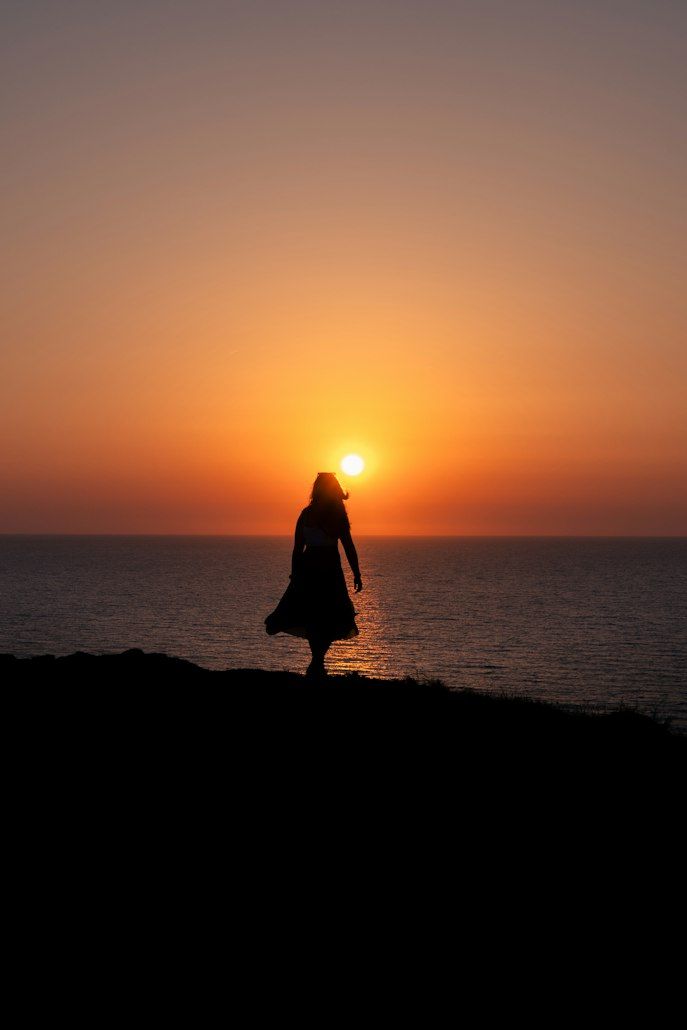

Upon the edge of land and light,
Where day surrenders to the night,
A silhouette against the blaze,
Lost within the amber haze.

The sun, a crown upon her brow,
Holds the world in silence now.
As waters catch the fading gold,
A quiet story starts to unfold.

With every step, the shadows grow,
In the embers of the ocean’s glow,
She stands alone, a fleeting grace,
Caught in time’s embrace.

In [19]:
IMAGE_URL = "https://images.unsplash.com/photo-1789207051591-05b3c423cc14?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"

answer = multimodal_gemini.stream(IMAGE_URL)

stream_response(answer)

### Hugging Face Inference API 활용하기

In [ ]:
# !pip install -qU huggingface_hub

In [ ]:
# !pip install ipywidgets

In [5]:
import os
from dotenv import load_dotenv
from langchain_teddynote import logging
from huggingface_hub import login

load_dotenv()
logging.langsmith("test0914")

print(os.getenv("HUGGINGFACEHUB_API_TOKEN")[:8] + "...")

LangSmith 추적을 시작합니다.
[프로젝트명]
test0914
hf_bPqMl...


In [6]:
login(os.getenv("HUGGINGFACEHUB_API_TOKEN"))

In [9]:
from langchain_core.prompts import PromptTemplate

template = """Question: {question}

Answer:"""

template = """<|system|>
You are a helpful assistant.<|end|>
<|user|>
Question?<|end|>
<|assistant|>
"""

prompt = PromptTemplate.from_template(template)

In [ ]:
# !pip install langchain_huggingface

In [3]:
import os
from langchain_core.output_parsers import StrOutputParser
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

repo_id = "microsoft/Phi-3-mini-4k-instruct"

llm = HuggingFaceEndpoint(
    repo_id=repo_id,
    max_new_tokens=256,
    temperature=0.1,
    huggingfacehub_api_token=os.environ["HUGGINGFACEHUB_API_TOKEN"],
    provider="featherless-ai"
)

chat_llm = ChatHuggingFace(llm=llm)

response = chat_llm.invoke("What is the capital city of the Netherlands?")
print(response.content)

The capital city of the Netherlands is Amsterdam.
